# Curso: Aplicações de Aprendizado de Máquina em Sistemas Embarcados

## Atividade Final 

Aluno: Marcos Cabanas Esteves

## Objetivos desta atividade
Avaliar o desempenho do modelo convertido para o formato TensorFlow Lite (TFLite), verificando se a acurácia obtida é adequada para implantação em dispositivos na borda.

In [14]:
# 1. Importar bibliotecas necessárias
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


## 2. Carregando modelo TFLite


In [15]:
# Caminho do modelo TFLite
tflite_model_path = 'model.tflite'  # ajuste se necessário

# Carregar o modelo TFLite
tflite_interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
tflite_interpreter.allocate_tensors()

# Verificar detalhes de entrada/saída
input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()
print('Input:', input_details)
print('Output:', output_details)


Input: [{'name': 'x', 'index': 0, 'shape': array([  1, 200,   3], dtype=int32), 'shape_signature': array([  1, 200,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'Identity', 'index': 32, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([1, 6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


## 3. Inserindo buffers de teste

In [ ]:
# Trecho do dataset para simular o buffer do app
wisdn_path = 'dataset/WISDM_ar_v1.1_raw.txt'
columns = ['user','activity','timestamp', 'x-axis', 'y-axis', 'z-axis']
df = pd.read_csv(wisdn_path, header=None, names=columns, on_bad_lines='skip', engine='python')

# Selecionar apenas uma atividade para teste (ex: Walking)
walking_df = df[df['activity'] == 'Walking'].reset_index(drop=True)

# Pegar um buffer de 200 amostras
buffer = walking_df[['x-axis', 'y-axis', 'z-axis']].iloc[:200].values.astype(np.float32)
print(buffer.shape)  # Deve ser (200, 3)

(200, 3)


## 4. Inferência no buffer

In [17]:
# Ajustar o shape para [1, 200, 3]
input_data = np.expand_dims(buffer, axis=0)

# Rodar inferência
tflite_interpreter.set_tensor(input_details[0]['index'], input_data)
tflite_interpreter.invoke()
output_data = tflite_interpreter.get_tensor(output_details[0]['index'])

# Mostrar resultado
print('Saída do modelo:', output_data)
activity_labels = ['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']
pred_idx = np.argmax(output_data)
print(f'Predição: {activity_labels[pred_idx]} (confiança: {output_data[0][pred_idx]:.2f})')


Saída do modelo: [[1.0121880e-04 1.1850233e-04 1.2665105e-05 9.7076172e-06 6.7878143e-05
  9.9969006e-01]]
Predição: Walking (confiança: 1.00)


## 5. Avaliar vários buffers e métricas

Nesta etapa vamos testar diferentes atividades e avaliar a acurácia, matriz de confusão e relatório de classificação.

In [18]:
# Avaliar vários buffers (um por atividade)
y_true = []
y_pred = []

for label in activity_labels:
    activity_df = df[df['activity'] == label].reset_index(drop=True)
    # Pega 10 buffers de cada atividade
    for i in range(10):
        buf = activity_df[['x-axis', 'y-axis', 'z-axis']].iloc[i*200:(i+1)*200].values.astype(np.float32)
        if buf.shape != (200, 3):
            continue
        input_data = np.expand_dims(buf, axis=0)
        tflite_interpreter.set_tensor(input_details[0]['index'], input_data)
        tflite_interpreter.invoke()
        output_data = tflite_interpreter.get_tensor(output_details[0]['index'])
        pred_idx = np.argmax(output_data)
        y_true.append(label)
        y_pred.append(activity_labels[pred_idx])

# Relatório de classificação
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred, target_names=activity_labels))


              precision    recall  f1-score   support

  Downstairs       0.56      1.00      0.71        10
     Jogging       1.00      1.00      1.00        10
     Sitting       1.00      1.00      1.00        10
    Standing       1.00      1.00      1.00        10
    Upstairs       1.00      0.20      0.33        10
     Walking       1.00      1.00      1.00        10

    accuracy                           0.87        60
   macro avg       0.93      0.87      0.84        60
weighted avg       0.93      0.87      0.84        60



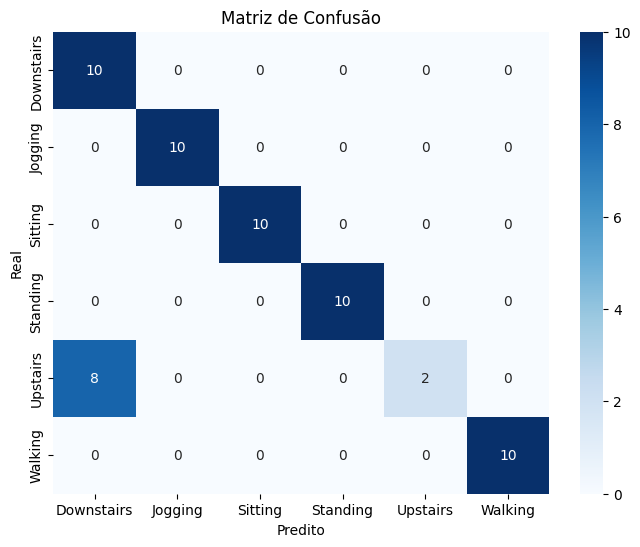

In [19]:
# Matriz de confusão
cm = confusion_matrix(y_true, y_pred, labels=activity_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=activity_labels, yticklabels=activity_labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()


## 6. Comparar predições vs valores reais

In [20]:
# Tabela de comparação
df_comp = pd.DataFrame({'Real': y_true, 'Predito': y_pred})
display(df_comp.head(20))

,Real,Predito
0,Downstairs,Downstairs
1,Downstairs,Downstairs
2,Downstairs,Downstairs
3,Downstairs,Downstairs
4,Downstairs,Downstairs
5,Downstairs,Downstairs
6,Downstairs,Downstairs
7,Downstairs,Downstairs
8,Downstairs,Downstairs
9,Downstairs,Downstairs
